In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [4]:
df.duplicated().sum()

np.int64(418)

In [5]:
df.drop_duplicates(keep = "last", inplace=True)

In [6]:
df.shape

(49582, 2)

In [7]:
labels = {"negative" : 0, "positive" : 1}

# Feature Target
X = df.review
y = df.sentiment

target = y.replace(labels).to_numpy()

In [8]:
y = target

## Text Processing

In [9]:
import re
import nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [10]:
lemmatizer = nltk.stem.WordNetLemmatizer()

In [11]:
def text_processor(text: str) -> str:
    text = text.lower()

    # HTML Tags, URLs, Puncuation and Special Chars
    text = re.sub(r"<.+?>", "", text) # HTML TAGS
    text = re.sub(r"[(http(s)?):\/\/(www\.)?a-zA-Z0-9@:%._\+~#=]{2,256}\.[a-z]{2,6}\b([-a-zA-Z0-9@:%_\+.~#?&//=]*)", "", text) # URLS
    text = re.sub(r"[^\w\d\s]", " ", text) # Puncuation or special Chars
    text = text.strip()
    
    # Stopwords
    text = [word for word in text.split() if word not in ENGLISH_STOP_WORDS]
    text = [word for word in text if len(word) > 2]
    text = " ".join(text)

    # Lemmatization
    text = lemmatizer.lemmatize(text)

    return text
    

In [12]:
feature = X.apply(text_processor).to_numpy()

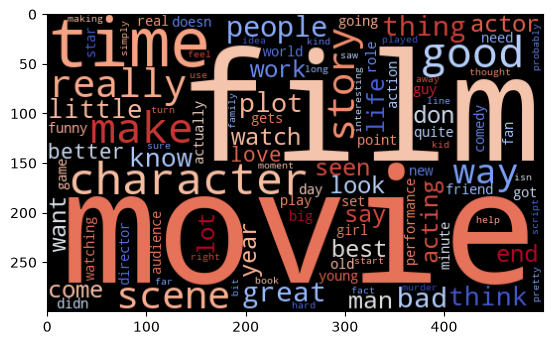

In [14]:
# Visualization

# !pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

cloud = WordCloud(
    colormap = "coolwarm", max_words=100, width=500, height=300
)
image = cloud.generate(" ".join(feature[:500]))

plt.imshow(image)

## Vectorize or Embeddings

In [75]:
# TFIDF Vectorizer
# WOR2Vec -> Train or pretrained
# BERT -> Pretrained

In [76]:
X = X.to_numpy()

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [78]:
from datasets import Dataset

train_data = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

test_data = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

In [80]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_data = train_data.map(tokenize_function, batched=True)
test_data = test_data.map(tokenize_function, batched=True)

Map: 100%|██████████| 9917/9917 [00:21<00:00, 464.63 examples/s]


In [81]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:01<00:00, 115.53it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

In [92]:
train_data_small = train_data.select(range(500))
test_data_small = test_data.select(range(100))

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(

    eval_strategy="epoch",
    save_strategy="no",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=1,

    weight_decay=0.01,

    logging_steps=50,
    report_to="none"
)

In [83]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [94]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data_small,
    eval_dataset=test_data_small,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.684421,0.654930,0.730000,0.622951,0.904762,0.737864


TrainOutput(global_step=63, training_loss=0.6814242620316763, metrics={'train_runtime': 1560.8863, 'train_samples_per_second': 0.32, 'train_steps_per_second': 0.04, 'total_flos': 65777763840000.0, 'train_loss': 0.6814242620316763, 'epoch': 1.0})

In [95]:
results = trainer.evaluate()

print(results)

c:\Users\bobs9\OneDrive\Desktop\Data science and Machine learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.684421,0.654930,1,0.730000,0.622951,0.904762,0.737864


{'eval_loss': 0.6549302935600281, 'eval_accuracy': 0.73, 'eval_precision': 0.6229508196721312, 'eval_recall': 0.9047619047619048, 'eval_f1': 0.7378640776699029}
